In [65]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

<h1 style="text-align: center;">ONLINE RETAIL SALES STORE DATASET</h1>

<strong>AIM:</strong>
<ul>
  <li>To analyze sales trends over time and identify peak revenue periods.</li>
  <li>To perform Customer Segmentation using RFM (Recency, Frequency, Monetary) modeling.</li>
  <li>To identify top-selling products and geographical regions driving the most revenue.</li>
</ul>

<h3>Dataset Attributes</h3>
<ul>
  <li><b>InvoiceNo:</b> Unique 6-digit transaction ID. (If it starts with 'C', it indicates a cancellation/return).</li>
  <li><b>StockCode:</b> Unique 5-digit product identifier.</li>
  <li><b>Description:</b> The name of the product.</li>
  <li><b>Quantity:</b> Number of units purchased in the transaction.</li>
  <li><b>InvoiceDate:</b> The exact date and time the purchase was made.</li>
  <li><b>UnitPrice:</b> The price of a single unit of the product.</li>
  <li><b>CustomerID:</b> Unique ID assigned to each customer.</li>
  <li><b>Country:</b> The country where the customer resides.</li>
</ul>

<h3>Notebook Contents</h3>
<ul>
  <li><b>Step 1: Data Import & Initial Exploration</b> (Loading the dataset, checking info, head, and summary statistics).</li>
  <li><b>Step 2: Data Cleaning</b> (Handling missing Customer IDs, removing duplicates, and filtering out returned/cancelled orders).</li>
  <li><b>Step 3: Feature Engineering</b> (Converting dates to datetime objects and creating a Total Revenue column).</li>
  <li><b>Step 4: Exploratory Data Analysis (EDA)</b> (Visualizing top-selling products, busiest shopping hours, and geographical sales).</li>
  <li><b>Step 5: RFM Analysis & Customer Segmentation</b> (Calculating Recency, Frequency, and Monetary scores to group customers).</li>
  <li><b>Step 6: Business Insights & Conclusion</b> (Summarizing actionable recommendations for marketing and inventory).</li>
</ul>

<h3>What You will Learn</h3>
<ul>
  <li>How to clean, filter, and preprocess messy real-world e-commerce transaction logs.</li>
  <li>Techniques for extracting time-series trends and seasonal patterns from raw datetime data.</li>
  <li>The mathematical logic and business application of RFM (Recency, Frequency, Monetary) customer segmentation.</li>
  <li>How to translate raw Python visualizations into actionable marketing and inventory strategies.</li>
</ul>

<h3>Recent Work</h3>
<ul>
  <li><b>ValueSpec AI:</b> An end-to-end Machine Learning web application for predicting fair laptop prices, fully deployed to production via Render.</li>
  <li><b>Open Source Contributor:</b> Technical documentation contributions to the Scrapy web scraping framework on GitHub.</li>
</ul>

<br>
<h3 style="text-align: center; color: #fff; border-top: 2px solid #ccc; padding-top: 20px;">Let the work begin</h3>

<h3>Import the necessary libraries:</h3>

In [66]:
import pandas as pd
import numpy as np
import re
import joblib
import random as rnd
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

<h3>Data info:</h3>

In [67]:
df = pd.read_csv(r'/kaggle/input/datasets/ulrikthygepedersen/online-retail-dataset/online_retail.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [68]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


<h3>Phase 1: Initial Data Exploration</h3>
<p>Before altering any data, we must understand the health of our dataset. We will check the dimensions, look for missing values, and identify anomalies to plan our cleaning strategy.</p>
<ul>
    <li><b>shape & info():</b> To understand the size and data types.</li>
    <li><b>isnull().sum():</b> To locate missing data that could skew our analysis.</li>
    <li><b>duplicated().sum():</b> To find system errors or accidental double-checkouts.</li>
    <li><b>nunique():</b> To understand the actual scale of the business, including the total number of unique customers, products, and countries.</li>
    <li><b>describe():</b> To get a statistical summary of numerical data, identify averages, and spot anomalies like negative quantities (returns).</li>
    <li><b>columns:</b> To extract a quick reference list of all available features for our analysis.</li>
    <li><b>dtypes:</b> To verify how Pandas is reading our data, ensuring numerical and date columns are in the correct format before doing calculations.</li>
</ul>

In [69]:
df.shape

(541909, 8)

<h6></h6>

In [70]:
df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

In [71]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [72]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [73]:
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [75]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [76]:
df.duplicated().sum()

np.int64(5268)

<h3>Visualizing Missing Data (Heatmap)</h3>
<p>While the isnull().sum() command gives the raw numbers, a heatmap provides a visual map of where the missing data is located. The bright colors instantly highlight the gaps across the columns. In this dataset, the heatmap visually confirms the massive block of missing Customer IDs, proving exactly why the column needs to be cleaned before attempting any customer segmentation.</p>

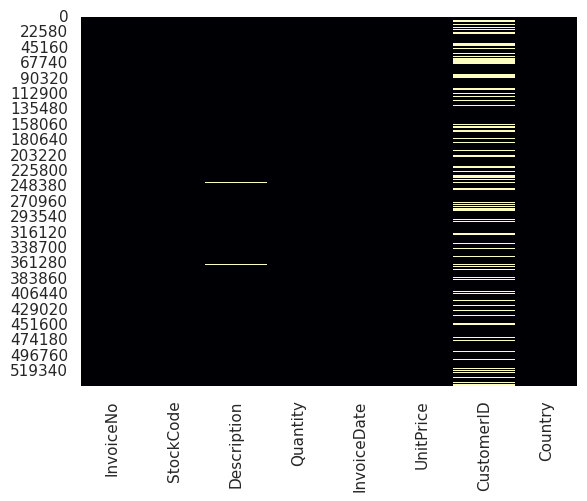

In [77]:
sns.heatmap(df.isnull(),cmap = 'magma',cbar = False);

<h3>Step 1: Removing Duplicate Transactions</h3>
<p>I identified over 5,000 duplicate rows. In retail, this usually represents a system glitch where a transaction was logged twice. I must remove these so as to avoid inflating company's revenue numbers.</p>

In [78]:
df = df.drop_duplicates()
df.shape

(536641, 8)

<h3>Step 2: Handling Missing Customer IDs</h3>
<p>I have over 130,000 rows with no CustomerID. Because the primary goal is Customer Segmentation through RFM Analysis, a transaction without a customer attached to it is useless to to the company. I will drop these rows to ensure customer behavior models are 100% accurate and with no errors.</p>

In [79]:

df = df.dropna(subset=['CustomerID'])
df.shape

(401604, 8)

<h3>Step 3: Formatting Customer IDs</h3>
<p>Currently, CustomerID is stored as a float (e.g., 17850.0). IDs are categorical labels, not mathematical numbers. I will convert them to integers, and then to strings, so they are treated as unique labels rather than decimals.</p>

In [80]:
df['CustomerID'] = df['CustomerID'].astype(int).astype(str)
df['CustomerID'].dtype

dtype('O')

<h3>Step 4: Datetime Conversion</h3>
<p>To analyze seasonal trends, peak shopping hours, and calculate the "Recency" of a customer's last purchase, Python needs to recognize InvoiceDate as a proper Date/Time object, not just a string of text.</p>
<span>M8 is short for datetime64, and [ns] specifies nanosecond precision.</span>

In [81]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['InvoiceDate'].dtype

dtype('<M8[ns]')

<h3>Step 5: Filtering Out Returns and Cancellations</h3>
<p>In this dataset, cancelled orders have a negative Quantity. If i am to leave them in, they will silently subtract from our total sales analysis. To avoid issues later, it is best to filter the dataset to only include successful, positive transactions.</p>

In [82]:

df = df[df['Quantity'] > 0]
df.shape

(392732, 8)

<h3>Step 6: Feature Engineering (Total Revenue)</h3>
<p>The dataset points out Quantity and UnitPrice, but to find our most valuable customers and best-selling products, i need the total amount spent per line item. To get the total price, i need to multiply the quantity of goods bought and the price of goods per unit. This in turn requires feature engineering so as to create a new column called TotalPrice.</p>

In [83]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


<h3>1. How I Calculate the Metrics (The Math)</h3>
<p>To build this model, I have to group my entire dataset by CustomerID. I am going to compress hundreds of thousands of rows down to just one row per customer, containing three specific numbers:</p>
<ul>
    <li><b>Recency (R) -> Uses InvoiceDate:</b> I will find the very last day in my entire dataset, and then calculate exactly how many days have passed since a specific customer's most recent purchase. If they bought yesterday, their Recency is 1. If they bought last Christmas, their Recency is 300+.</li>
    <li><b>Frequency (F) -> Uses InvoiceNo:</b> I will count the number of unique invoices attached to a customer. <i>Note: I do not use Quantity for this.</i> If a customer buys 50 items in one order, their frequency is 1, not 50. Frequency is about how many distinct trips they made to the store.</li>
    <li><b>Monetary (M) -> Uses TotalPrice:</b> I will simply sum up the new TotalPrice column I engineered for every item that customer ever bought to find their total lifetime spend.</li>
</ul>

<h3>2. Assigning the Scores (The Logic)</h3>
<p>Once I have those three numbers for every customer, I will let Python rank them from 1 to 5 using quantiles (percentiles).</p>
<ul>
    <li><b>R-Score:</b> A customer who bought yesterday gets a 5. A customer who bought 10 months ago gets a 1.</li>
    <li><b>F-Score:</b> A customer who has ordered 50 times gets a 5. A one-time buyer gets a 1.</li>
    <li><b>M-Score:</b> A customer who spent £10,000 gets a 5. A customer who spent £10 gets a 1.</li>
</ul>

<h3>3. Creating the Segments (The Business Value)</h3>
<p>This is where the magic happens. I will combine those scores into a single RFM string to segment the customer base.</p>
<ul>
    <li><b>The "555" Customer (Champions):</b> High Recency, High Frequency, High Monetary. I do not give these people massive discounts because they are already buying! I give them VIP early access to new products.</li>
    <li><b>The "155" Customer (Can't Lose Them):</b> Low Recency (haven't seen them in months), High Frequency (used to buy all the time), High Monetary (spent a ton of money). This is my primary discount target. I would send them a massive "We Miss You - 30% Off" campaign to win back their heavy spending.</li>
    <li><b>The "111" Customer (Hibernating):</b> Bought once a year ago, spent £5. The business shouldn't waste marketing budget sending targeted emails to these people.</li>
</ul>

<h1 style = "text-align: center;">Visual Exploratory Data Analysis (EDA)</h1>

<p>Before I dive into the complex RFM segmentation, I want to understand the general sales trends of the business. Visualizing the data helps me quickly identify which products are driving the most volume and which countries are generating the most revenue. This ensures that any business recommendations I make are grounded in actual sales performance.</p>
<ul>
    <li><b>Top 10 Best-Selling Products:</b> Essential for inventory planning and supply chain management.</li>
    <li><b>Top 10 Countries by Revenue:</b> Crucial for allocating marketing budgets and identifying geographical expansion opportunities.</li>
</ul>

#Graph 1: Top 10 Best-Selling Products (by Quantity)

#Group by Description, sum the Quantity, and get the top 10

#Graph 2: Top 10 Countries by Total Revenue

#Group by Country, sum the TotalPrice, and get the top 10


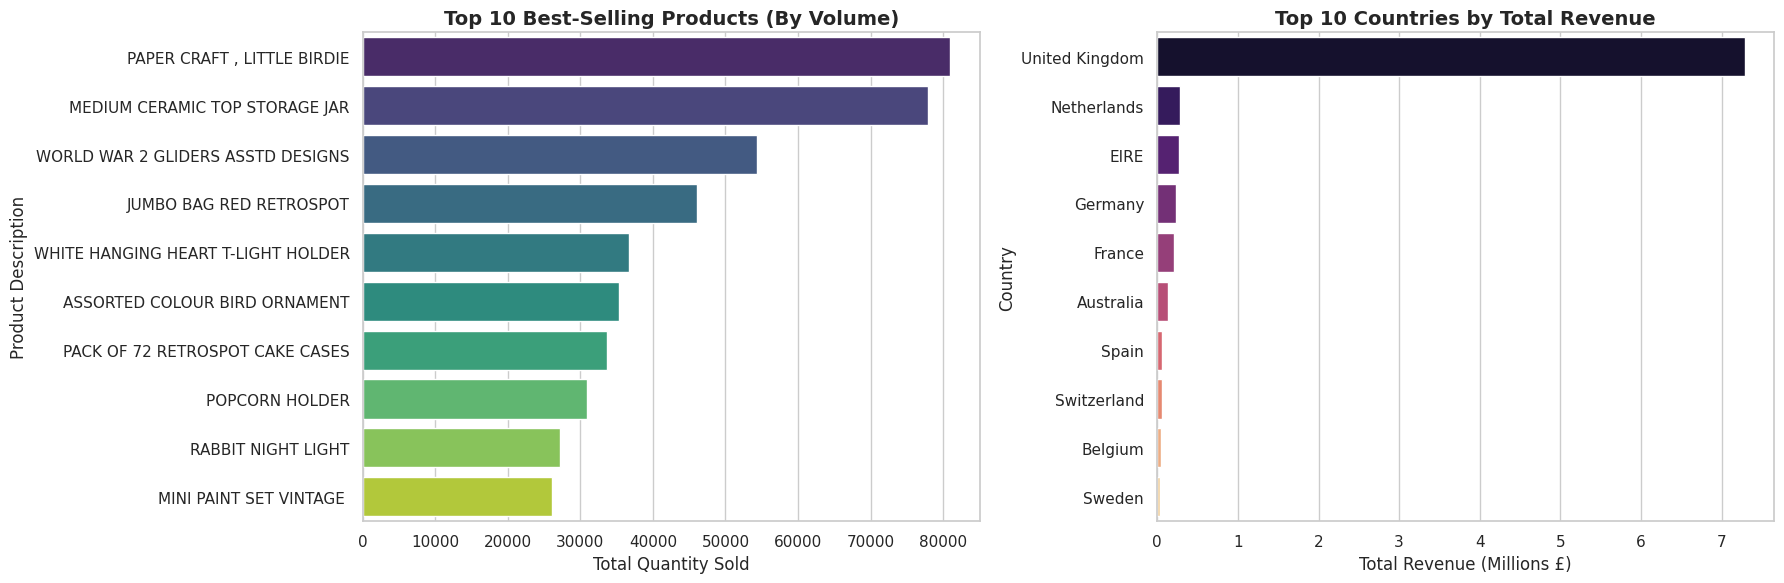

In [84]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index, ax=axes[0], palette="viridis", legend=False)
axes[0].set_title('Top 10 Best-Selling Products (By Volume)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Quantity Sold', fontsize=12)
axes[0].set_ylabel('Product Description', fontsize=12)

top_countries = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

top_countries_millions = top_countries / 1000000

sns.barplot(x=top_countries_millions.values, y=top_countries_millions.index, hue=top_countries_millions.index, ax=axes[1], palette="magma", legend=False)
axes[1].set_title('Top 10 Countries by Total Revenue', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Revenue (Millions £)', fontsize=12)
axes[1].set_ylabel('Country', fontsize=12)

plt.tight_layout()
plt.show()

<h3>Time-Series Analysis: Revenue Trends</h3>
<p>Understanding <i>when</i> customers buy is just as important as knowing <i>what</i> they buy. In this section, I will analyze the total revenue generated across different months and days of the week.</p>
<ul>
    <li><b>Monthly Revenue Trends:</b> This helps in forecasting and planning inventory for peak seasons (like the holiday rush).</li>
    <li><b>Daily Revenue Trends:</b> This identifies the busiest days of the week, which is crucial for scheduling customer service staff and timing marketing emails.</li>
</ul>
<p>To accomplish this, I will extract the Month and the Day of the Week from the InvoiceDate column, group the data, and visualize the total revenue in millions.</p>

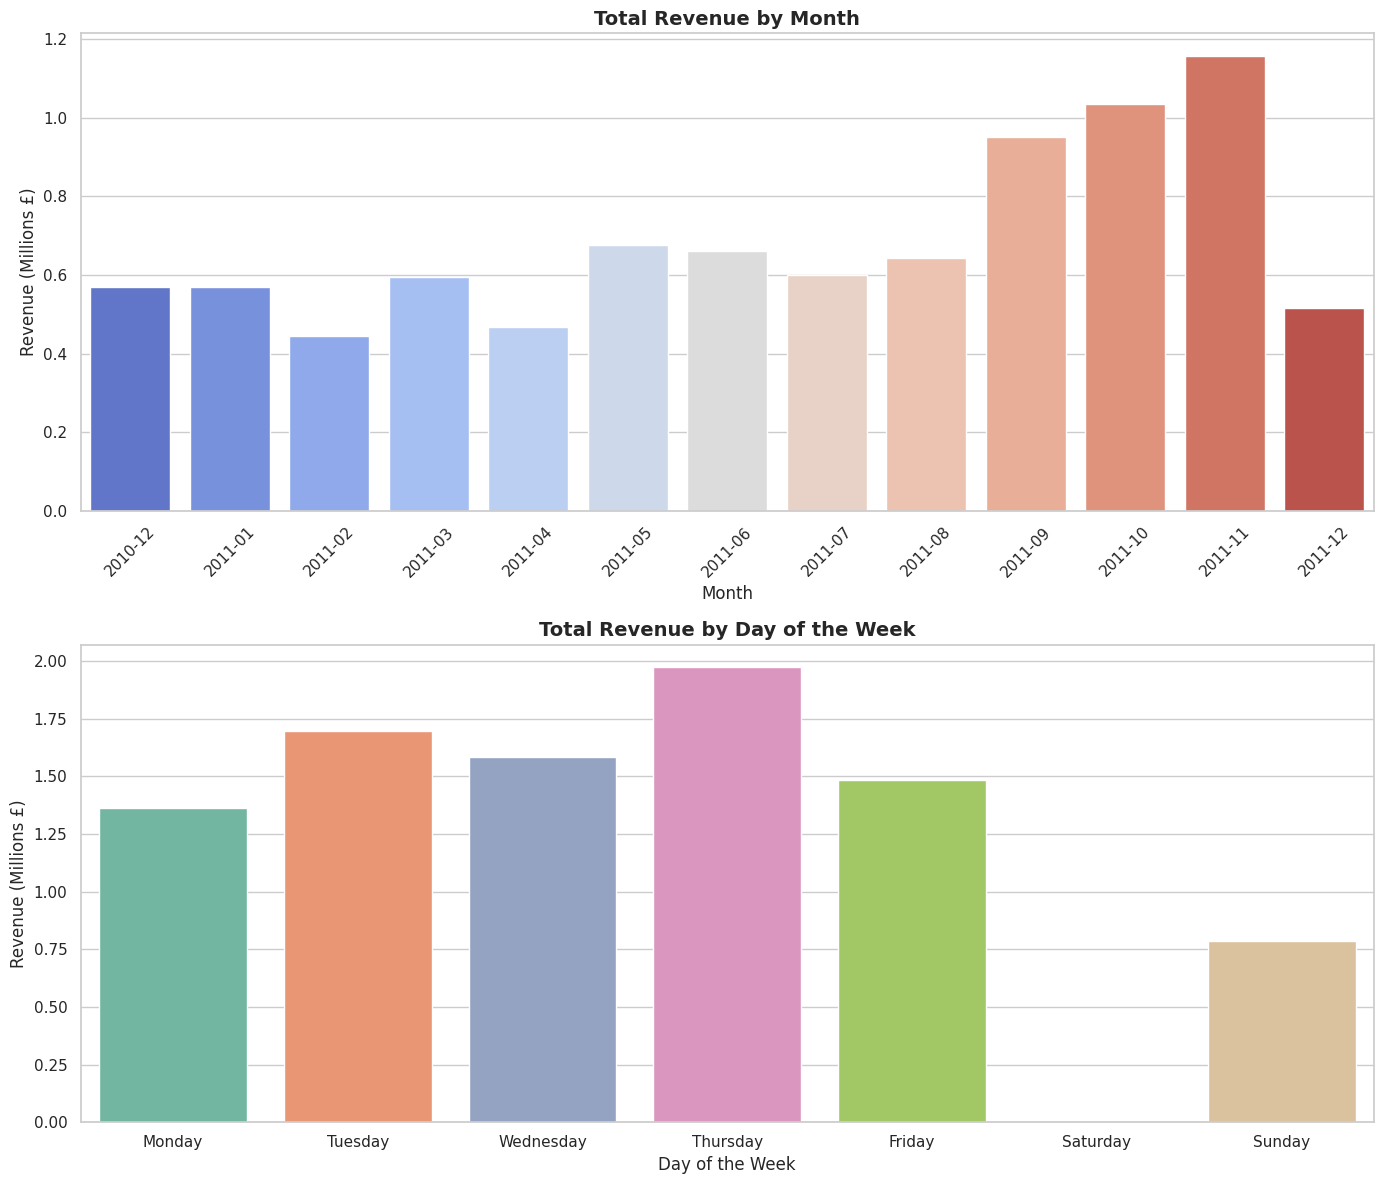

In [85]:
df['Month'] = df['InvoiceDate'].dt.to_period('M').astype(str)
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

monthly_revenue = df.groupby('Month')['TotalPrice'].sum() / 1000000

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_revenue = df.groupby('DayOfWeek')['TotalPrice'].sum().reindex(day_order) / 1000000

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

sns.barplot(x=monthly_revenue.index, y=monthly_revenue.values, hue=monthly_revenue.index, ax=axes[0], palette="coolwarm", legend=False)
axes[0].set_title('Total Revenue by Month', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month', fontsize=12)
axes[0].set_ylabel('Revenue (Millions £)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x=daily_revenue.index, y=daily_revenue.values, hue=daily_revenue.index, ax=axes[1], palette="Set2", legend=False)
axes[1].set_title('Total Revenue by Day of the Week', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Day of the Week', fontsize=12)
axes[1].set_ylabel('Revenue (Millions £)', fontsize=12)

plt.tight_layout()
plt.show()

<h3>Building the RFM Model</h3>
<p>Now I am transitioning from general sales trends to individual customer behavior. To build the RFM (Recency, Frequency, Monetary) model, I need to consolidate my dataset so that each row represents a single unique customer.</p>
<ul>
    <li><b>Recency:</b> How many days have passed since the customer's last purchase? (Calculated by subtracting their most recent invoice date from a 'snapshot' date of the current dataset).</li>
    <li><b>Frequency:</b> How many total, unique orders has the customer placed?</li>
    <li><b>Monetary Value:</b> What is the total sum of money the customer has spent across all their orders?</li>
</ul>

In [86]:
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


<h3>Understanding the Raw RFM Output</h3>
<p>Here is exactly what the first few rows tell us about these specific customers:</p>
<ul>
    <li><b>Customer 12346:</b> Recency: 326 | Frequency: 1 | Monetary: £77,183. They spent a fortune on a single order but haven't returned in almost a year. <b>Action:</b> Contact them directly to find out why they stopped buying.</li>
    <li><b>Customer 12347:</b> Recency: 2 | Frequency: 7 | Monetary: £4,310. They buy often, spend consistently, and just bought 2 days ago. This is a perfect, loyal customer.</li>
    <li><b>Customer 12349:</b> Recency: 19 | Frequency: 1 | Monetary: £1,757. They bought less than 3 weeks ago and spent a good amount on their first order. <b>Action:</b> Send a welcome discount to encourage a second purchase.</li>
    <li><b>Customer 12350:</b> Recency: 310 | Frequency: 1 | Monetary: £334. They bought once almost a year ago, spent very little, and never came back. <b>Action:</b> Do not waste marketing budget trying to win them back.</li>
</ul>

<h3>Assigning RFM Scores (1 to 5)</h3>
<p>Now that I have the raw Recency, Frequency, and Monetary values for every customer, I need to rank them on a scale of 1 to 5. I will use Pandas <code>qcut()</code> (Quantile-based discretization function) to divide my customers into 5 equal percentiles.</p>
<ul>
    <li><b>R-Score:</b> Lower recency is better (they bought recently). The lowest 20% of days get a score of 5.</li>
    <li><b>F-Score & M-Score:</b> Higher is better. The top 20% of spenders and frequent buyers get a score of 5.</li>
</ul>
<p>Finally, I will concatenate these three numbers into a single string (e.g., "555") to create the final <b>RFM Segment</b> label for each customer.</p>

<span>(Note: We use .rank(method='first') on Frequency because so many customers buy exactly 1 time, it causes a tie-breaker issue if we don't rank them first!)</span>

In [87]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])

rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

rfm['RFM_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score
0,12346,326,1,77183.60,1,1,5,115,7
1,12347,2,7,4310.00,5,5,5,555,15
2,12348,75,4,1797.24,2,4,4,244,10
3,12349,19,1,1757.55,4,1,4,414,9
4,12350,310,1,334.40,1,1,2,112,4


<h3>Decoding the RFM Scores</h3>
<p>After calculating the raw numbers, I ranked my customers on a scale of 1 to 5. Here is exactly what each new column means:</p>
<ul>
    <li><b>R_Score (Recency):</b> Scored from 1 to 5. A score of <b>5</b> is the best (they bought very recently). A score of <b>1</b> is the worst (they haven't been seen in months).</li>
    <li><b>F_Score (Frequency):</b> Scored from 1 to 5. A score of <b>5</b> means they order all the time. A score of <b>1</b> means they only ordered once.</li>
    <li><b>M_Score (Monetary):</b> Scored from 1 to 5. A score of <b>5</b> means they spend a massive amount of money. A score of <b>1</b> means they spend very little.</li>
    <li><b>RFM_Segment:</b> This combines the three scores into a single text string (like "555" or "142"). I will use this exact code to group customers into marketing buckets (e.g., all "555" customers are Champions).</li>
    <li><b>RFM_Score:</b> This is the mathematical sum of the three scores (R + F + M). A perfect customer gets a 15 (5+5+5). The worst possible customer gets a 3 (1+1+1). This gives me a quick "overall health" grade for every buyer.</li>
</ul>

<h3>Customer Segmentation Mapping</h3>
<p>Now that every customer has an R and F score from 1 to 5, I will use a python function to categorize them. By looking at how recently they bought (Recency) and how often they buy (Frequency), I can assign them into specific marketing tiers:</p>
<ul>
    <li><b>Champions:</b> High R (4-5), High F (4-5). They bought recently and buy often.</li>
    <li><b>Loyal Customers:</b> Good R (3), Good F (3+). They buy regularly.</li>
    <li><b>New Customers:</b> High R (4-5), Low F (1-2). They bought very recently, but only once or twice.</li>
    <li><b>Can't Lose Them:</b> Low R (1-2), High F (4-5). They used to buy all the time, but haven't been seen in months.</li>
    <li><b>At Risk:</b> Low R (1-2), Average F (3). Spent money in the past, but fading away.</li>
    <li><b>Hibernating:</b> Low R (1-2), Low F (1-2). Bought a long time ago and rarely return.</li>
</ul>

In [88]:
def assign_segment(row):
    r = row['R_Score']
    f = row['F_Score']
    
    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r == 3 and f <= 2:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 4:
        return "Can't Lose Them"
    elif r <= 2 and f == 3:
        return 'At Risk'
    else:
        return 'Hibernating'

rfm['Customer_Segment'] = rfm.apply(assign_segment, axis=1)

segment_counts = rfm['Customer_Segment'].value_counts()
print(segment_counts)

Customer_Segment
Champions              1139
Hibernating            1065
Loyal Customers         821
At Risk                 367
Potential Loyalists     351
New Customers           320
Can't Lose Them         276
Name: count, dtype: int64


<h3>Visualizing the Customer Segments</h3>
<p>With every customer officially categorized, I will visualize the distribution of our customer base. This bar chart instantly highlights the health of the business.</p>
<ul>
    <li><b>The Highs:</b> A large number of 'Champions' indicates a strong core product and high customer loyalty.</li>
    <li><b>The Lows:</b> A massive 'Hibernating' group shows that our retention strategy for first-time buyers needs serious improvement.</li>
    <li><b>The Opportunity:</b> The 'Can't Lose Them' segment represents our immediate target for aggressive win-back email campaigns.</li>
</ul>

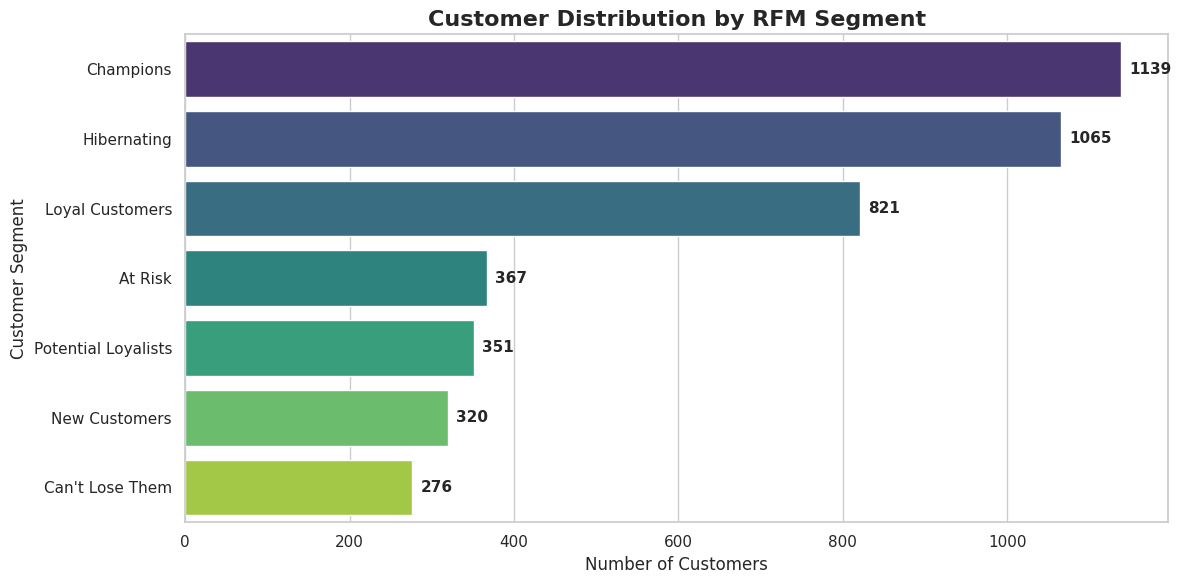

In [89]:
plt.figure(figsize=(12, 6))

sns.barplot(x=segment_counts.values, y=segment_counts.index, hue=segment_counts.index, palette="viridis", legend=False)

plt.title('Customer Distribution by RFM Segment', fontsize=16, fontweight='bold')
plt.xlabel('Number of Customers', fontsize=12)
plt.ylabel('Customer Segment', fontsize=12)

for index, value in enumerate(segment_counts.values):
    plt.text(value + 10, index, str(value), va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

<h3>Revenue by Customer Segment</h3>
<p>Knowing how many customers are in each segment is helpful, but knowing exactly how much money they generate is critical. In retail, the Pareto Principle often applies: a very small percentage of top customers generates the vast majority of the total revenue.</p>
<ul>
    <li><b>The Financial Impact:</b> This chart proves to stakeholders exactly why the business must invest heavily in VIP retention programs for the 'Champions' segment.</li>
    <li><b>The ROI:</b> It justifies the marketing spend for targeted win-back campaigns aimed at the 'Can't Lose Them' group, as they historically hold high monetary value.</li>
</ul>

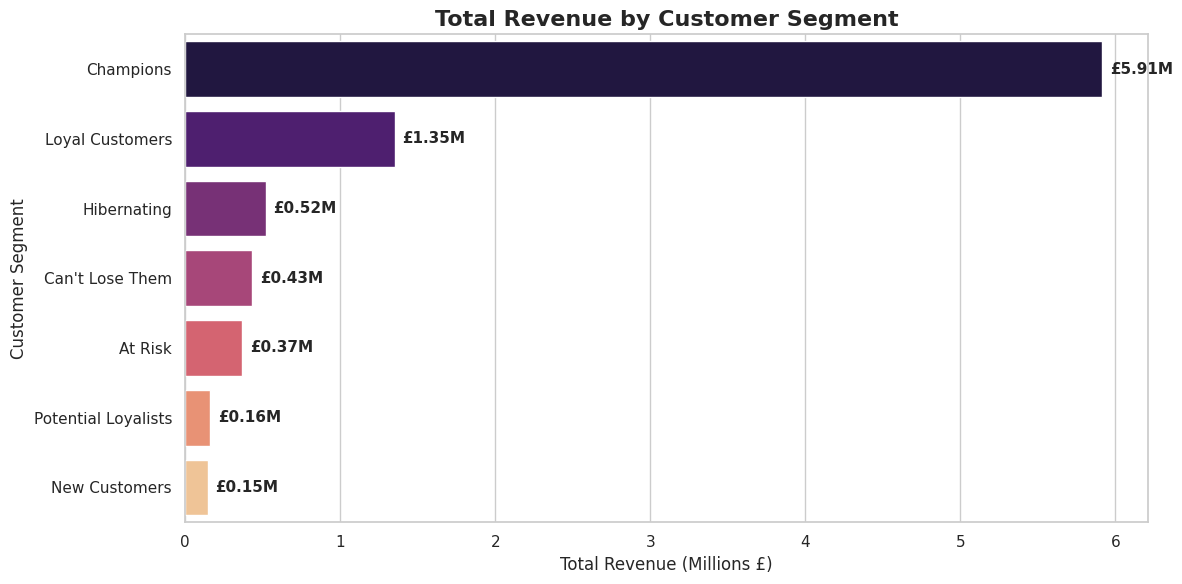

In [90]:
revenue_by_segment = rfm.groupby('Customer_Segment')['Monetary'].sum().sort_values(ascending=False) / 1000000

plt.figure(figsize=(12, 6))

sns.barplot(x=revenue_by_segment.values, y=revenue_by_segment.index, hue=revenue_by_segment.index, palette="magma", legend=False)

plt.title('Total Revenue by Customer Segment', fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue (Millions £)', fontsize=12)
plt.ylabel('Customer Segment', fontsize=12)

for index, value in enumerate(revenue_by_segment.values):
    plt.text(value + 0.05, index, f"£{value:.2f}M", va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

<h3 style = "text-align: center;">Machine Learning: K-Means Clustering</h3>
<p>While human-defined RFM rules are highly effective, Machine Learning can discover hidden patterns we might miss. I will use the K-Means algorithm to mathematically group customers based on their purchasing behavior.</p>
<ul>
    <li><b>Handling Outliers (Log Transformation):</b> Because some customers spent £70,000 and others spent £5, the data is highly skewed. I will use a mathematical Log Transformation to pull these extreme outliers closer to the center, making it easier for the algorithm to read.</li>
    <li><b>Standardizing the Data (StandardScaler):</b> K-Means calculates physical distance between data points. I must scale Recency, Frequency, and Monetary to have the exact same weight (mean of 0, variance of 1) so that the £77,000 Monetary value doesn't overpower the 2-day Recency value.</li>
</ul>

In [91]:
rfm_ml = rfm[['Recency', 'Frequency', 'Monetary']].copy()

rfm_ml = rfm_ml.clip(lower=1)

rfm_log = np.log(rfm_ml)

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'], index=rfm.index)

rfm_scaled_df.head()

,Recency,Frequency,Monetary
0,1.410138,-1.048362,3.690261
1,-2.146411,1.111943,1.410201
2,0.384170,0.490670,0.718983
3,-0.574518,-1.048362,0.701336
4,1.375000,-1.048362,-0.609951


<h3 style = "text-align: center;">Finding the Optimal Clusters: Using the Elbow Method</h3>
<p>Before applying the K-Means algorithm, I need to determine the optimal number of customer clusters (k). I will use the Elbow Method to calculate the Within-Cluster Sum of Squares (WCSS) for 1 to 10 clusters.</p>
<ul>
    <li><b>WCSS (Inertia):</b> This measures how tightly packed the clusters are. A lower number is better, but it naturally decreases as we add more clusters.</li>
    <li><b>The "Elbow":</b> I will look for the point on the line graph where the steep drop-off suddenly slows down and levels out. That exact point represents the mathematically optimal number of customer segments.</li>
</ul>

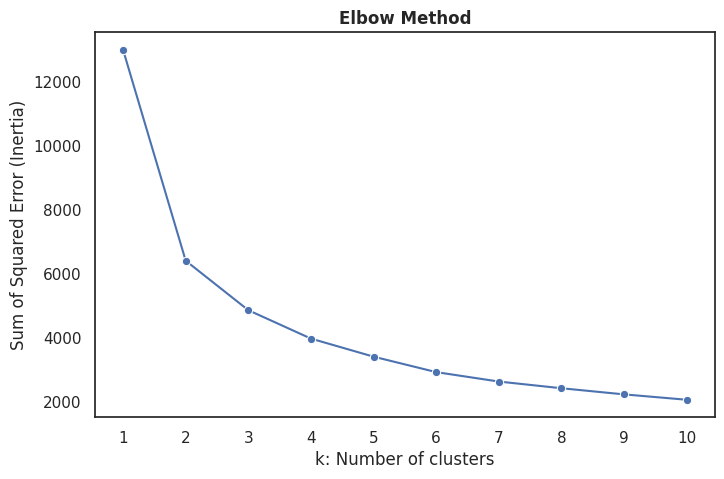

In [92]:
sns.set_style("white")

wcss = []
k_range_elbow = range(1, 11)

for k in k_range_elbow:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(rfm_scaled_df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
sns.lineplot(x=k_range_elbow, y=wcss, marker='o', color='b')
plt.title('Elbow Method', fontweight='bold')
plt.xlabel('k: Number of clusters')
plt.ylabel('Sum of Squared Error (Inertia)')
plt.xticks(k_range_elbow)
plt.show()

<h3 style = "text-align: center;">Confirming Clusters with the Silhouette Score</h3>
<p>Because the Elbow Method produced a gradual curve rather than a sharp bend, I will use the Silhouette Score to mathematically confirm the optimal number of clusters. The Silhouette Score measures how similar an object is to its own cluster compared to other clusters. A higher score indicates better-defined clusters.</p>

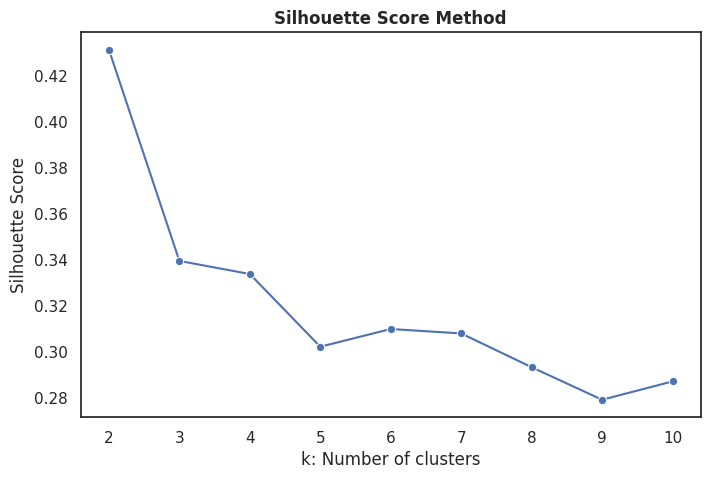

In [93]:
sns.set_style("white")

sil_scores = []
k_range_sil = range(2, 11)

for k in k_range_sil:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled_df)
    sil_scores.append(silhouette_score(rfm_scaled_df, labels))

plt.figure(figsize=(8, 5))
sns.lineplot(x=k_range_sil, y=sil_scores, marker='o', color='b')
plt.title('Silhouette Score Method', fontweight='bold')
plt.xlabel('k: Number of clusters')
plt.ylabel('Silhouette Score')
plt.xticks(k_range_sil)
plt.show()

<p>From the results of the above 2 methods, we select :</p>
<li>k : Clusters = 2</li>

<h3 style = "text-align:center;">Generating Multiple Clustering Options for Business Review</h3>
<p>While the mathematical models (Elbow and Silhouette) suggest 2 clusters, business teams often require more granular segments for targeted marketing. To provide the stakeholders with the best options, I will run the K-Means algorithm for 2, 3, and 4 clusters and attach the labels to the dataset.</p>
<ul>
    <li><b>Cluster_2:</b> The mathematical ideal (usually splits into "High Value" and "Low Value").</li>
    <li><b>Cluster_3:</b> A balanced business approach (e.g., "VIP", "Average", "Low Value").</li>
    <li><b>Cluster_4:</b> A highly detailed business approach (e.g., "VIP", "Loyal", "New", "Lost").</li>
</ul>
<p>This allows the marketing team to review the size and value of each segment before finalizing their campaign strategy.</p>

In [94]:
kmeans_2 = KMeans(n_clusters=2, init='k-means++', random_state=42, n_init=10)
rfm['Cluster_2'] = kmeans_2.fit_predict(rfm_scaled_df)

kmeans_3 = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
rfm['Cluster_3'] = kmeans_3.fit_predict(rfm_scaled_df)

kmeans_4 = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
rfm['Cluster_4'] = kmeans_4.fit_predict(rfm_scaled_df)

print("--- 2 CLUSTERS ---")
print(rfm['Cluster_2'].value_counts().sort_index())
print("\n--- 3 CLUSTERS ---")
print(rfm['Cluster_3'].value_counts().sort_index())
print("\n--- 4 CLUSTERS ---")
print(rfm['Cluster_4'].value_counts().sort_index())

--- 2 CLUSTERS ---
Cluster_2
0    1762
1    2577
Name: count, dtype: int64

--- 3 CLUSTERS ---
Cluster_3
0    1861
1     781
2    1697
Name: count, dtype: int64

--- 4 CLUSTERS ---
Cluster_4
0    1262
1    1573
2     741
3     763
Name: count, dtype: int64


<h3>Understanding the Machine Learning Output</h3>
<p>The K-Means algorithm has successfully sorted our customers into three different "menus" of options (2 groups, 3 groups, and 4 groups). Here is exactly how to read those results:</p>
<ul>
    <li><b>The 0s, 1s, 2s, and 3s:</b> These are simply the blank "name tags" the machine gave to each group. Group 0 is not mathematically worse than Group 1; they are just different neighborhoods (like "Group A" and "Group B"). The machine doesn't know English words like "VIP", so it uses numbers.</li>
    <li><b>The Large Numbers:</b> This is the exact headcount of customers assigned to that specific group.</li>
</ul>
<p><b>For Example:</b> Under the "3 CLUSTERS" option, seeing <code>0: 1861</code> and <code>1: 781</code> means the machine found 1,861 people who shop very similarly and put them in Group 0, and another 781 people who shop similarly and put them in Group 1.</p>

<h3>Profiling All Machine Learning Clusters (2, 3, and 4)</h3>
<p>To understand exactly who makes up these newly created clusters across all three options, I will calculate the average Recency, Frequency, and Monetary value for every single group. By looking at these averages, I can translate the machine's numerical labels into real business names.</p>
<ul>
    <li><b>High Monetary / High Frequency / Low Recency:</b> This group will be our "Champions" or VIPs.</li>
    <li><b>High Recency (Days) / Low Frequency / Low Monetary:</b> This group will be our "Lost" or "Hibernating" customers.</li>
    <li><b>Average across the board:</b> This group will be our "Regulars".</li>
</ul>
</ul>

In [96]:
profile_2 = rfm.groupby('Cluster_2').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(2)

print("--- 2 CLUSTERS PROFILE ---")
print(profile_2)

--- 2 CLUSTERS PROFILE ---
          Recency Frequency Monetary      
             mean      mean     mean count
Cluster_2                                 
0           27.99      8.16  4358.96  1762
1          136.64      1.61   468.26  2577


In [97]:
profile_3 = rfm.groupby('Cluster_3').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(2)

print("\n--- 3 CLUSTERS PROFILE ---")
print(profile_3)


--- 3 CLUSTERS PROFILE ---
          Recency Frequency Monetary      
             mean      mean     mean count
Cluster_3                                 
0          161.31      1.27   339.05  1861
1           13.25     13.04  7608.19   781
2           53.56      3.53  1363.72  1697


In [98]:
profile_4 = rfm.groupby('Cluster_4').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(2)

print("\n--- 4 CLUSTERS PROFILE ---")
print(profile_4)


--- 4 CLUSTERS PROFILE ---
          Recency Frequency Monetary      
             mean      mean     mean count
Cluster_4                                 
0           71.42      4.15  1743.55  1262
1          183.74      1.27   344.98  1573
2           10.44     13.22  7793.55   741
3           19.06      1.97   483.83   763


<h3>Decoding the Cluster Options (2, 3, and 4)</h3>
<p>To give the marketing team the best options for targeted campaigns, here is the exact breakdown of the above customer behavior under each of the three clustering models:</p>

<h4>Option 1: The 2-Cluster Model (The Basic Split)</h4>
<ul>
    <li><b>Cluster 0 (High Value):</b> Spend an average of £4,358, buy frequently (8 times), and visited recently (28 days ago).</li>
    <li><b>Cluster 1 (Low Value/Lost):</b> Spend an average of £468, buy rarely (1.6 times), and haven't visited in months (136 days ago).</li>
</ul>

<h4>Option 2: The 3-Cluster Model (The Balanced Approach)</h4>
<ul>
    <li><b>Cluster 1 (The VIPs):</b> Massive spenders (£7,608 avg), buy very often (13 times), and visited just 13 days ago.</li>
    <li><b>Cluster 2 (The Regulars):</b> Solid middle-tier customers spending £1,363 and buying around 3 to 4 times.</li>
    <li><b>Cluster 0 (The Lost):</b> Lowest value, spending just £339 and haven't visited in over 5 months (161 days avg).</li>
</ul>

<h4>Option 3: The 4-Cluster Model (The Highly Targeted Approach)</h4>
<ul>
    <li><b>Cluster 2 (The VIPs):</b> Our absolute best customers (£7,793 avg spend, 13 purchases).</li>
    <li><b>Cluster 0 (The Regulars):</b> Consistent buyers (£1,743 avg spend, 4 purchases).</li>
    <li><b>Cluster 3 (New/Promising):</b> Low spend (£483) and low frequency (2 purchases), but visited very recently (19 days ago). These are prime targets for a "second-purchase" discount campaign.</li>
    <li><b>Cluster 1 (Lost/Hibernating):</b> Lowest value (£344) and haven't been seen in over 6 months (183 days).</li>
</ul>

<h3 style = "text-align:center;">Visualizing the Customer Segments in 3D</h3>
<p>To fully understand the spatial relationship between our customer segments, I have plotted the standardized Recency, Frequency, and Monetary values on a 3D axis. This visualizes how the K-Means algorithm separated the customers for the 2, 3, and 4-cluster options.</p>
<ul>
    <li><b>X-Axis:</b> Recency</li>
    <li><b>Y-Axis:</b> Frequency</li>
    <li><b>Z-Axis:</b> Monetary Value</li>
</ul>

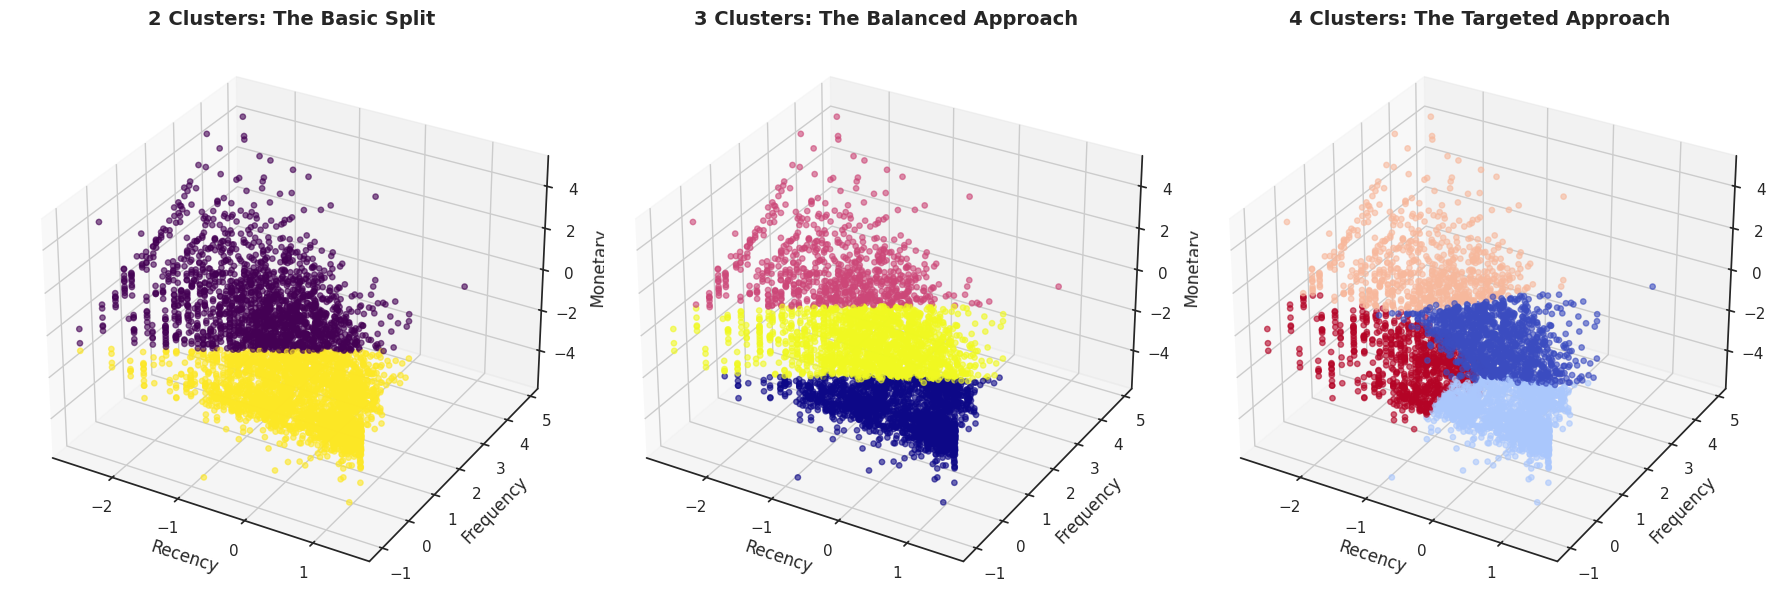

In [99]:
x = rfm_scaled_df.iloc[:, 0]
y = rfm_scaled_df.iloc[:, 1]
z = rfm_scaled_df.iloc[:, 2]

fig = plt.figure(figsize=(18, 6))

ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(x, y, z, c=rfm['Cluster_2'], cmap='viridis', s=15, alpha=0.6)
ax1.set_title('2 Clusters: The Basic Split', fontweight='bold', fontsize=14)
ax1.set_xlabel('Recency')
ax1.set_ylabel('Frequency')
ax1.set_zlabel('Monetary')

ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(x, y, z, c=rfm['Cluster_3'], cmap='plasma', s=15, alpha=0.6)
ax2.set_title('3 Clusters: The Balanced Approach', fontweight='bold', fontsize=14)
ax2.set_xlabel('Recency')
ax2.set_ylabel('Frequency')
ax2.set_zlabel('Monetary')

ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(x, y, z, c=rfm['Cluster_4'], cmap='coolwarm', s=15, alpha=0.6)
ax3.set_title('4 Clusters: The Targeted Approach', fontweight='bold', fontsize=14)
ax3.set_xlabel('Recency')
ax3.set_ylabel('Frequency')
ax3.set_zlabel('Monetary')

plt.tight_layout()
plt.show()

<h3>Understanding the 3D Scatter Plots</h3>
<p>Here is a visual breakdown of what the colors and positions represent in the 3D space across our different models:</p>

<b>1. The 2-Cluster Model (Left Plot)</b>
<ul>
    <li><b>Purple (Cluster 0 - High Value):</b> Floating high up on the Z-axis (Monetary) and Y-axis (Frequency), and close to zero on the X-axis (Low Recency).</li>
    <li><b>Yellow (Cluster 1 - Low Value/Lost):</b> Flat on the bottom (low spend, low frequency) and stretched far out to the right on the X-axis (high recency).</li>
</ul>

<b>2. The 3-Cluster Model (Middle Plot)</b>
<ul>
    <li><b>Pink (Cluster 1 - The VIPs):</b> Towering over the rest on the Z-axis with the highest spend.</li>
    <li><b>Yellow (Cluster 2 - The Regulars):</b> Forming a solid, thick band right in the middle of the dataset.</li>
    <li><b>Dark Blue (Cluster 0 - The Lost):</b> Flat on the floor and stretched out into the high-recency zone.</li>
</ul>

<b>3. The 4-Cluster Model (Right Plot)</b>
<p>This model gives the clearest distinct groups for marketing strategies:</p>
<ul>
    <li><b>Orange (Cluster 2 - The VIPs):</b> Positioned at the very top for highest spend and highest frequency.</li>
    <li><b>Dark Blue (Cluster 0 - The Regulars):</b> Floating steadily in the middle ranges.</li>
    <li><b>Dark Red (Cluster 3 - New/Promising):</b> Low spend and frequency (flat on the bottom), but pushed right up against the 0 mark on the X-axis, meaning they bought very recently.</li>
    <li><b>Light Blue (Cluster 1 - Lost/Hibernating):</b> The lowest value customers pushed all the way to the far right side of the Recency axis.</li>
</ul>

<h2 align="center">Results Summary</h2>

<p><b>Cluster Optimization Tests (The Math):</b></p>
<table>
  <tr>
    <th>Sr. No.</th>
    <th>Evaluation Method</th>
    <th>Mathematical Optimal Clusters (k)</th>
  </tr>
  <tr>
    <td>1.</td>
    <td>Elbow Method (Inertia)</td>
    <td>2</td>
  </tr>
  <tr>
    <td>2.</td>
    <td>Silhouette Score Method</td>
    <td>2</td>
  </tr>
</table>

<br>

<p><b>Business Strategy Options (For Stakeholder Review):</b></p>
<table>
  <tr>
    <th>Option</th>
    <th>Clusters</th>
    <th>Customer Segments Created</th>
    <th>Best Use Case for Marketing Team</th>
  </tr>
  <tr>
    <td><b>Option 1</b></td>
    <td>2</td>
    <td>High Value / Low Value</td>
    <td>A simple, binary split. Best for broad, high-level campaigns with limited budgets.</td>
  </tr>
  <tr>
    <td><b>Option 2</b></td>
    <td>3</td>
    <td>VIPs / Regulars / Lost</td>
    <td>A balanced approach. Best for standard retention and re-engagement programs.</td>
  </tr>
  <tr>
    <td><b>Option 3</b></td>
    <td>4</td>
    <td>VIPs / Regulars / New / Lost</td>
    <td>A highly targeted approach. Best for personalized marketing and "second-purchase" discounts.</td>
  </tr>
</table>

<h2 align="center">Conclusion</h2>

<ul>
    <li>This online retail dataset provided an excellent opportunity to apply unsupervised machine learning to a real-world business problem. By utilizing RFM (Recency, Frequency, Monetary) analysis, we successfully transformed raw transactional data into actionable behavioral segments.</li>
    <br>
    <li>For unsupervised learning problems, data preprocessing is critical. Because K-Means is a distance-based algorithm, applying standard scaling to the highly skewed Monetary and Frequency variables ensured that no single feature dominated the model.</li>
    <br>
    <li>For the K-Means algorithm, statistical tests (Elbow Method and Silhouette Score) strongly pointed to <b>k=2</b> as the mathematically optimal split. However, pure mathematics does not always give marketing teams the granularity they need.</li>
    <br>
    <li>Instead of forcing a single choice, the model was run for 2, 3, and 4 clusters. This empowers the business stakeholders to review the size and value of each segment and select the final model that best aligns with their current advertising capacity and strategy.</li>
</ul>

<br><br>
<h3 align="center">Please upvote if you found this work helpful!</h3>

<h4>Exporting cleaned dataset to csv</h4>

In [100]:
rfm.to_csv('rfm_customer_segments.csv', index=False)